<a href="https://colab.research.google.com/github/josecarlosencabo/Master-Thesis/blob/main/Master_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Libraries
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_excel('esg_dataset.xlsx')

# Define the variables used in the analysis
outcomes = ['Env_score', 'Social_score', 'Gov_score']
treatments = ['Toxic_chem_red', 'Recycling_Initiatives', 'Human_Rights',
              'Strikes', 'Bribery', 'Shareholder_Rights']
controls = ['Market_cap', 'FNCL_LVRG', 'RETURN_ON_ASSET', 'ASSET_GROWTH']

# Keep only the relevant columns
cols_to_check = outcomes + treatments + controls

# Remove rows with missing values
df_clean = df.dropna(subset=cols_to_check)

# Calculate descriptive statistics
summary_stats = df_clean[cols_to_check].describe().T

# Print the summary table
print(summary_stats[['count', 'mean', 'std', 'min', '50%', 'max']])

                       count          mean           std           min  \
Env_score              598.0  5.271193e+01  2.534379e+01  5.684755e-01   
Social_score           598.0  5.893887e+01  1.808095e+01  8.277894e+00   
Gov_score              598.0  5.873223e+01  1.938755e+01  4.901173e+00   
Toxic_chem_red         598.0  2.391304e-01  4.269096e-01  0.000000e+00   
Recycling_Initiatives  598.0  1.454849e-01  3.528843e-01  0.000000e+00   
Human_Rights           598.0  7.357860e-01  4.412829e-01  0.000000e+00   
Strikes                598.0  5.351171e-02  2.252400e-01  0.000000e+00   
Bribery                598.0  9.765886e-01  1.513327e-01  0.000000e+00   
Shareholder_Rights     598.0  1.000000e+00  0.000000e+00  1.000000e+00   
Market_cap             598.0  4.526368e+10  3.992004e+10  6.474417e+09   
FNCL_LVRG              598.0  7.530653e+00  3.330568e+01  1.159500e+00   
RETURN_ON_ASSET        598.0  8.114416e+00  5.578604e+00 -1.814280e+01   
ASSET_GROWTH           598.0  8.086291

In [5]:
# Print all column names in the clean dataset
print(df_clean.columns.tolist())

['Identifier (RIC)', 'Company Name', 'Date', 'ESG_score', 'Social_score', 'Gov_score', 'Env_score', 'BVPS', 'Market_cap', 'Shares', 'Industry', 'Net_income', 'RETURN_ON_ASSET', 'QUICK_RATIO', 'ASSET_GROWTH', 'FNCL_LVRG', 'PE_RATIO', 'Scope_1', 'Scope_2', 'CO2_emissions', 'Energy_use', 'Water_use', 'Water_recycle', 'Toxic_chem_red', 'Injury_rate', 'Women_Employees', 'Human_Rights', 'Strikes', 'Turnover_empl', 'Board_Size', 'Shareholder_Rights', 'Board_gen_div', 'Bribery', 'Recycling_Initiatives', 'Total_assets']


In [17]:
# Count the number of unique firms in the clean sample
n_firms = df_clean['Identifier (RIC)'].nunique()
print('Number of firms:', n_firms)

# Check the exact standard deviation of Shareholder_Rights before rounding
print('Shareholder_Rights std (exact):', df_clean['Shareholder_Rights'].std())

Number of firms: 69
Shareholder_Rights std (exact): 0.0


In [6]:
import pandas as pd
from IPython.display import display, HTML

# Round all values to two decimal places
table = summary_stats[['count', 'mean', 'std', 'min', '50%', 'max']].round(2)

# Rename columns to cleaner labels
table.columns = ['N', 'Mean', 'Std. Dev.', 'Min', 'Median', 'Max']

# Fix Market_cap to show in billions for readability
table.loc['Market_cap', ['Mean', 'Std. Dev.', 'Min', 'Median', 'Max']] = (
    table.loc['Market_cap', ['Mean', 'Std. Dev.', 'Min', 'Median', 'Max']] / 1e9
).round(2)

# Build the note split into two lines
note_line1 = "Note: Market_cap is expressed in billions of US dollars. Binary treatment variables take values of 0 or 1."
note_line2 = "N = 598 firm year observations across 69 US industrial firms, 2012 to 2021."

# Convert table to HTML and inject large font size into table cells
table_html = table.to_html()
table_html = table_html.replace('<table', '<table style="font-size: 20px; margin: auto;"')
table_html = table_html.replace('<th', '<th style="padding: 8px 16px;"')
table_html = table_html.replace('<td', '<td style="padding: 8px 16px;"')

# Wrap everything in a centered div and display
display(HTML("""
    <div style='text-align: center;'>
        <p style='font-weight: bold; font-size: 22px;'>Table 1. Descriptive Statistics</p>
        <div style='display: inline-block; text-align: center;'>
""" + table_html + """
        </div>
        <p style='font-size: 18px;'><i>""" + note_line1 + """<br>""" + note_line2 + """</i></p>
    </div>
"""))

,N,Mean,Std. Dev.,Min,Median,Max
Env_score,598.0,52.71,25.34,0.57,58.01,96.47
Social_score,598.0,58.94,18.08,8.28,59.49,97.39
Gov_score,598.0,58.73,19.39,4.90,61.06,94.56
Toxic_chem_red,598.0,0.24,0.43,0.00,0.00,1.00
Recycling_Initiatives,598.0,0.15,0.35,0.00,0.00,1.00
Human_Rights,598.0,0.74,0.44,0.00,1.00,1.00
Strikes,598.0,0.05,0.23,0.00,0.00,1.00
Bribery,598.0,0.98,0.15,0.00,1.00,1.00
Shareholder_Rights,598.0,1.00,0.00,1.00,1.00,1.00
Market_cap,598.0,45.26,39.92,6.47,29.50,184.90


In [7]:
# Install the econml library
!pip install econml

In [8]:
import numpy as np
import pandas as pd
from econml.dml import LinearDML
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# Define the five treatment outcome pairs
treatment_outcome_pairs = [
    ('Toxic_chem_red', 'Env_score'),
    ('Recycling_Initiatives', 'Env_score'),
    ('Human_Rights', 'Social_score'),
    ('Strikes', 'Social_score'),
    ('Bribery', 'Gov_score')
]

# Define the financial controls
controls = ['Market_cap', 'FNCL_LVRG', 'RETURN_ON_ASSET', 'ASSET_GROWTH']

# Store results
dml_results = []

# Loop over each treatment outcome pair
for treatment, outcome in treatment_outcome_pairs:

    # Select relevant columns from the clean sample
    df_model = df_clean[[outcome, treatment] + controls].dropna()

    # Define outcome, treatment and controls
    Y = df_model[outcome].values
    T = df_model[treatment].values
    W = df_model[controls].values
    n_obs = len(df_model)

    # Store ATE point estimates across 20 random splits
    ate_list = []

    # Run 20 random splits and collect point estimates
    for seed in range(20):

        # Fit the DML model using default LassoCV and logistic regression for treatment
        model = LinearDML(
            model_y=LassoCV(),
            model_t=LogisticRegressionCV(cv=5, random_state=seed),
            discrete_treatment=True,
            cv=5,
            random_state=seed
        )
        model.fit(Y, T, X=None, W=W, inference='auto')

        # Extract and store the ATE point estimate
        ate_list.append(model.ate(X=None))

    # Fit one final representative model with seed 42 to extract the confidence interval
    # Note: the CI belongs to this single run, not to the averaged ATE across splits
    final_model = LinearDML(
        model_y=LassoCV(),
        model_t=LogisticRegressionCV(cv=5, random_state=42),
        discrete_treatment=True,
        cv=5,
        random_state=42
    )
    final_model.fit(Y, T, X=None, W=W, inference='auto')

    # Extract confidence interval from the representative model
    ci = final_model.ate_interval(X=None, alpha=0.05)

    # Compute mean and sample standard deviation of ATE across the 20 splits
    mean_ate = np.mean(ate_list)
    std_ate = np.std(ate_list, ddof=1)

    # Store the final results
    dml_results.append({
        'Treatment': treatment,
        'Outcome': outcome,
        'ATE (mean)': round(mean_ate, 4),
        'Std across splits': round(std_ate, 4),
        'CI Lower (seed 42)': round(ci[0], 4),
        'CI Upper (seed 42)': round(ci[1], 4),
        'N': n_obs
    })

    # Print progress
    print(f'Done: {treatment} -> {outcome}')

# Convert results to a dataframe and print
dml_results_df = pd.DataFrame(dml_results)
print(dml_results_df)

/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=0) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=1) has a non-default cv attribute, which will be ignored
  warnings.warn(f"

Done: Toxic_chem_red -> Env_score


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=0) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=1) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=2) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Mod

Done: Recycling_Initiatives -> Env_score


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=0) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=1) has a non-default cv attribute, which will be ignored
  warnings.warn(f"

Done: Human_Rights -> Social_score


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=0) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=1) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Done: Strikes -> Social_score


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=0) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=1) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=5, random_state=2) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs f

Done: Bribery -> Gov_score
               Treatment       Outcome  ATE (mean)  Std across splits  \
0         Toxic_chem_red     Env_score      7.4628             0.1610   
1  Recycling_Initiatives     Env_score     10.6185             0.1108   
2           Human_Rights  Social_score     17.6118             0.0243   
3                Strikes  Social_score      3.4437             0.1139   
4                Bribery     Gov_score     -0.3179             0.1563   

   CI Lower (seed 42)  CI Upper (seed 42)    N  
0              3.7425             10.8915  598  
1              6.5357             14.4955  598  
2             14.9767             20.2640  598  
3             -0.6791              7.4477  598  
4             -6.9641              6.3513  598  


In [9]:
import pandas as pd
from IPython.display import display, HTML

# Build the formatted results table
table_dml = pd.DataFrame({
    'Treatment': ['Toxic_chem_red', 'Recycling_Initiatives', 'Human_Rights', 'Strikes', 'Bribery'],
    'Outcome': ['Env_score', 'Env_score', 'Social_score', 'Social_score', 'Gov_score'],
    'ATE': [7.4628, 10.6185, 17.6118, 3.4437, -0.3179],
    'Std across splits': [0.1610, 0.1108, 0.0243, 0.1139, 0.1563],
    'CI Lower (95%)': [3.7425, 6.5357, 14.9767, -0.6791, -6.9641],
    'CI Upper (95%)': [10.8915, 14.4955, 20.2640, 7.4477, 6.3513],
    'N': [598, 598, 598, 598, 598]
})

# Round all numeric columns to two decimal places
table_dml = table_dml.round(2)

# Convert table to HTML and inject font size
table_html = table_dml.to_html(index=False)
table_html = table_html.replace('<table', '<table style="font-size: 20px; margin: auto;"')
table_html = table_html.replace('<th', '<th style="padding: 8px 16px;"')
table_html = table_html.replace('<td', '<td style="padding: 8px 16px;"')

# Build the table note
note_line1 = "Note: ATE is the mean across 20 random splits. Std across splits is the sample standard deviation of the ATE estimates across the 20 splits."
note_line2 = "CI Lower and CI Upper report the 95% confidence interval from a representative run with seed 42. N = 598 firm year observations."

# Display everything centered
display(HTML("""
    <div style='text-align: center;'>
        <p style='font-weight: bold; font-size: 22px;'>Table 2. Double Machine Learning Results</p>
        <div style='display: inline-block; text-align: center;'>
""" + table_html + """
        </div>
        <p style='font-size: 18px;'><i>""" + note_line1 + "<br>" + note_line2 + """</i></p>
    </div>
"""))

Treatment,Outcome,ATE,Std across splits,CI Lower (95%),CI Upper (95%),N
Toxic_chem_red,Env_score,7.46,0.16,3.74,10.89,598
Recycling_Initiatives,Env_score,10.62,0.11,6.54,14.50,598
Human_Rights,Social_score,17.61,0.02,14.98,20.26,598
Strikes,Social_score,3.44,0.11,-0.68,7.45,598
Bribery,Gov_score,-0.32,0.16,-6.96,6.35,598


In [10]:
import numpy as np
import pandas as pd
from econml.grf import CausalForest

# Define the five treatment outcome pairs
treatment_outcome_pairs = [
    ('Toxic_chem_red', 'Env_score'),
    ('Recycling_Initiatives', 'Env_score'),
    ('Human_Rights', 'Social_score'),
    ('Strikes', 'Social_score'),
    ('Bribery', 'Gov_score')
]

# Define the financial controls
controls = ['Market_cap', 'FNCL_LVRG', 'RETURN_ON_ASSET', 'ASSET_GROWTH']

# Store summary results and individual predictions
cf_results = []
ite_predictions = {}

# Loop over each treatment outcome pair
for treatment, outcome in treatment_outcome_pairs:

    # Select relevant columns from the clean sample
    df_model = df_clean[[outcome, treatment] + controls].dropna()

    # Define outcome, treatment and controls
    # fit signature is fit(X, T, y)
    X = df_model[controls].values
    T = df_model[treatment].values
    Y = df_model[outcome].values
    n_obs = len(df_model)

    # Fit the Causal Forest with stability settings for small samples
    cf = CausalForest(
        n_estimators=2000,
        min_samples_leaf=10,
        max_depth=5,
        random_state=42
    )
    cf.fit(X, T, Y)

    # Predict individual treatment effects for each observation
    ite = cf.predict(X).flatten()

    # Predict confidence intervals around the individual treatment effects
    ite_lower, ite_upper = cf.predict_interval(X, alpha=0.05)
    ite_lower = ite_lower.flatten()
    ite_upper = ite_upper.flatten()

    # Compute mean ITE and its confidence interval bounds averaged across firms
    mean_ite = np.mean(ite)
    mean_lower = np.mean(ite_lower)
    mean_upper = np.mean(ite_upper)

    # Compute standard deviation of ITE across firms to measure heterogeneity
    # Note: this is dispersion across firms, not inferential uncertainty
    std_ite = np.std(ite, ddof=1)

    # Compute the 10th and 90th percentiles to show the spread of effects
    p10 = np.percentile(ite, 10)
    p90 = np.percentile(ite, 90)

    # Store individual predictions for plotting later
    ite_predictions[f'{treatment}_{outcome}'] = ite

    # Store the summary results
    cf_results.append({
        'Treatment': treatment,
        'Outcome': outcome,
        'Mean ITE': round(mean_ite, 4),
        'Std ITE': round(std_ite, 4),
        'P10': round(p10, 4),
        'P90': round(p90, 4),
        'Mean CI Lower (95%)': round(mean_lower, 4),
        'Mean CI Upper (95%)': round(mean_upper, 4),
        'N': n_obs
    })

    # Print progress
    print(f'Done: {treatment} -> {outcome}')

# Convert results to a dataframe and print
cf_results_df = pd.DataFrame(cf_results)
print(cf_results_df)

Done: Toxic_chem_red -> Env_score
Done: Recycling_Initiatives -> Env_score
Done: Human_Rights -> Social_score
Done: Strikes -> Social_score
Done: Bribery -> Gov_score
               Treatment       Outcome  Mean ITE  Std ITE     P10      P90  \
0         Toxic_chem_red     Env_score    9.5643   5.8477  1.6438  17.3684   
1  Recycling_Initiatives     Env_score   13.7549   6.0795  8.3443  22.9387   
2           Human_Rights  Social_score   16.6878   5.1270  7.9839  22.9952   
3                Strikes  Social_score    7.8868   5.9464 -0.5286  15.2702   
4                Bribery     Gov_score    2.3228   5.3374 -3.4869   8.4930   

   Mean CI Lower (95%)  Mean CI Upper (95%)    N  
0               1.5746              17.5540  598  
1               4.5239              22.9859  598  
2              11.1835              22.1921  598  
3               0.0132              15.7603  598  
4              -6.6146              11.2601  598  


In [11]:
import pandas as pd
from IPython.display import display, HTML

# Build the formatted Causal Forest results table
table_cf = pd.DataFrame({
    'Treatment': ['Toxic_chem_red', 'Recycling_Initiatives', 'Human_Rights', 'Strikes', 'Bribery'],
    'Outcome': ['Env_score', 'Env_score', 'Social_score', 'Social_score', 'Gov_score'],
    'Mean ITE': [9.5643, 13.7549, 16.6878, 7.8868, 2.3228],
    'Std ITE': [5.8477, 6.0795, 5.1270, 5.9464, 5.3374],
    'P10': [1.6438, 8.3443, 7.9839, -0.5286, -3.4869],
    'P90': [17.3684, 22.9387, 22.9952, 15.2702, 8.4930],
    'CI Lower (95%)': [1.5746, 4.5239, 11.1835, 0.0132, -6.6146],
    'CI Upper (95%)': [17.5540, 22.9859, 22.1921, 15.7603, 11.2601],
    'N': [598, 598, 598, 598, 598]
})

# Round all numeric columns to two decimal places
table_cf = table_cf.round(2)

# Convert table to HTML and inject font size
table_html = table_cf.to_html(index=False)
table_html = table_html.replace('<table', '<table style="font-size: 20px; margin: auto;"')
table_html = table_html.replace('<th', '<th style="padding: 8px 16px;"')
table_html = table_html.replace('<td', '<td style="padding: 8px 16px;"')

# Build the table note
note_line1 = "Note: Mean ITE is the average of individual treatment effects predicted by the Causal Forest across all firms."
note_line2 = "Std ITE is the standard deviation of predicted effects across firms and measures heterogeneity, not inferential uncertainty."
note_line3 = "CI Lower and CI Upper are the means of the firm level 95% prediction intervals. P10 and P90 are the 10th and 90th percentiles of the ITE distribution. N = 598 firm year observations."

# Display everything centered
display(HTML("""
    <div style='text-align: center;'>
        <p style='font-weight: bold; font-size: 22px;'>Table 3. Causal Forest Results</p>
        <div style='display: inline-block; text-align: center;'>
""" + table_html + """
        </div>
        <p style='font-size: 18px;'><i>""" + note_line1 + "<br>" + note_line2 + "<br>" + note_line3 + """</i></p>
    </div>
"""))

Treatment,Outcome,Mean ITE,Std ITE,P10,P90,CI Lower (95%),CI Upper (95%),N
Toxic_chem_red,Env_score,9.56,5.85,1.64,17.37,1.57,17.55,598
Recycling_Initiatives,Env_score,13.75,6.08,8.34,22.94,4.52,22.99,598
Human_Rights,Social_score,16.69,5.13,7.98,23.00,11.18,22.19,598
Strikes,Social_score,7.89,5.95,-0.53,15.27,0.01,15.76,598
Bribery,Gov_score,2.32,5.34,-3.49,8.49,-6.61,11.26,598


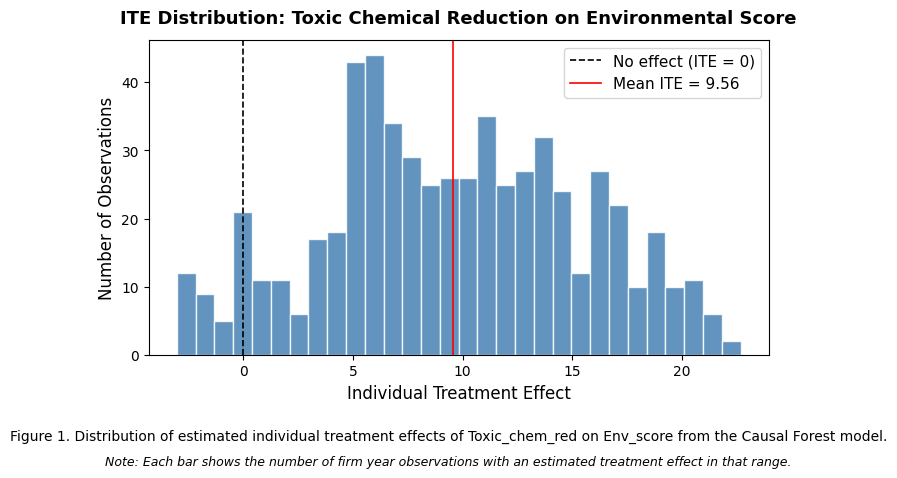

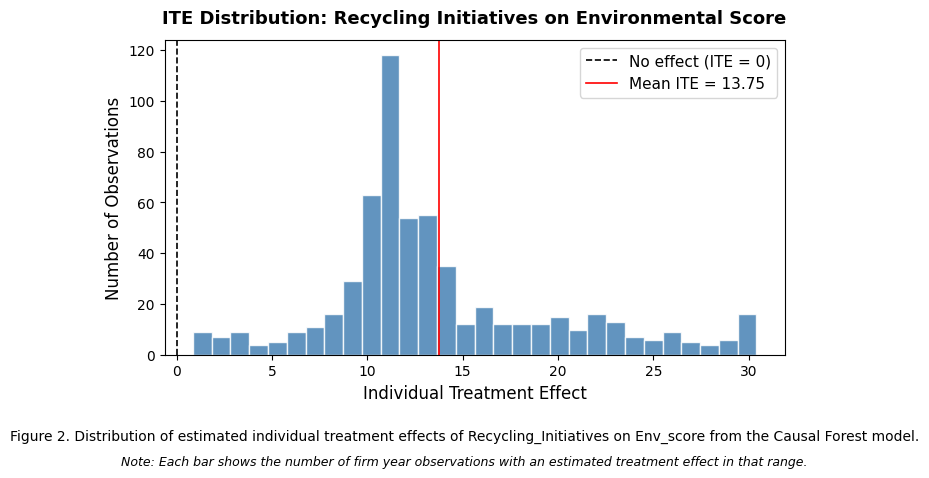

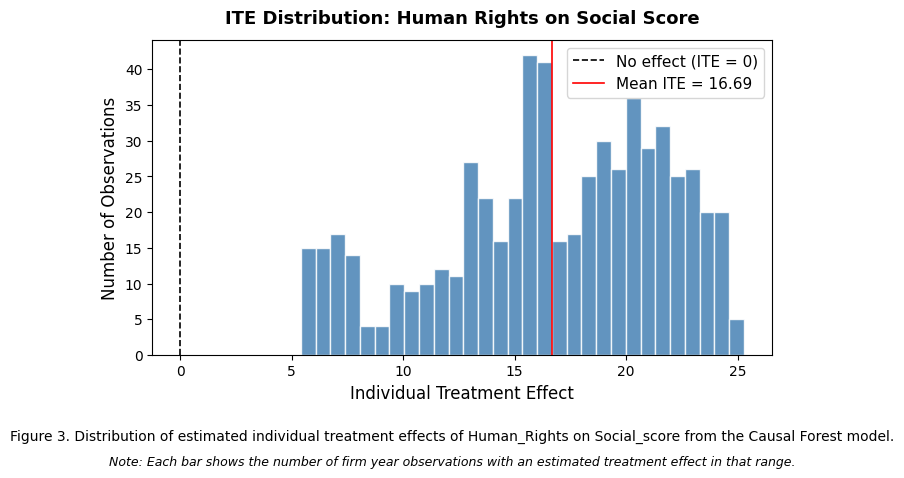

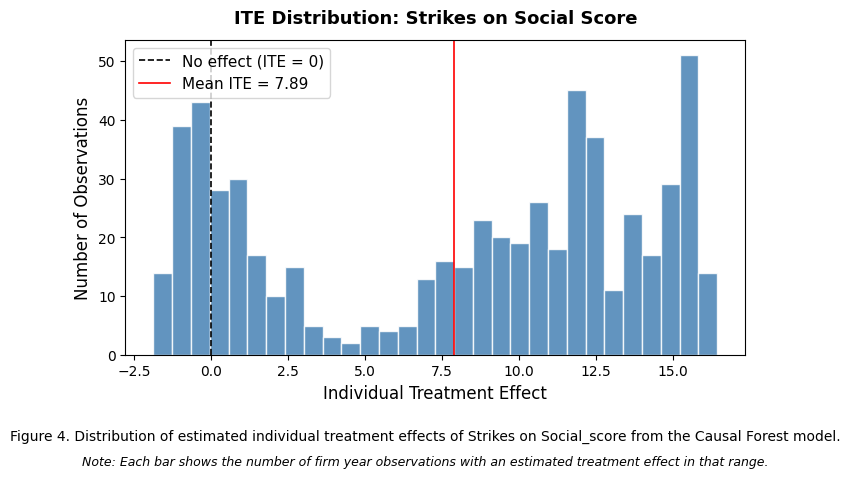

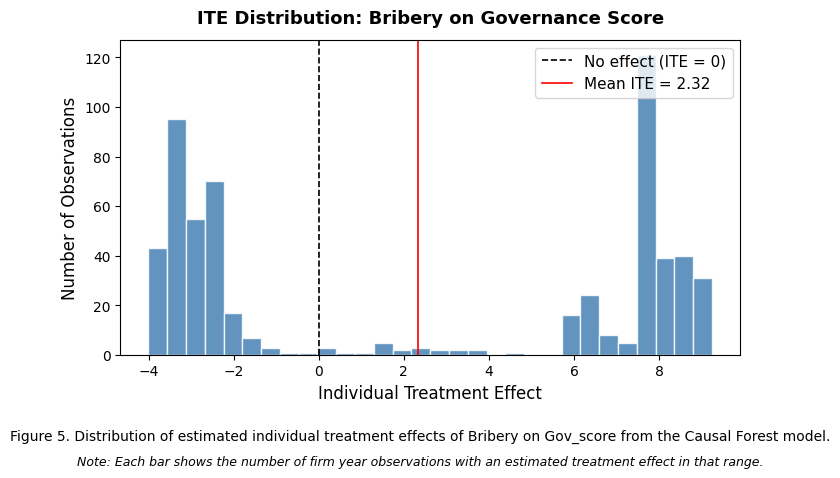

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Define the figure information
plot_labels = [
    (
        'Toxic_chem_red',
        'Env_score',
        'ITE Distribution: Toxic Chemical Reduction on Environmental Score',
        'Figure 1. Distribution of estimated individual treatment effects of Toxic_chem_red on Env_score from the Causal Forest model.',
        'Fig-1.jpg'
    ),
    (
        'Recycling_Initiatives',
        'Env_score',
        'ITE Distribution: Recycling Initiatives on Environmental Score',
        'Figure 2. Distribution of estimated individual treatment effects of Recycling_Initiatives on Env_score from the Causal Forest model.',
        'Fig-2.jpg'
    ),
    (
        'Human_Rights',
        'Social_score',
        'ITE Distribution: Human Rights on Social Score',
        'Figure 3. Distribution of estimated individual treatment effects of Human_Rights on Social_score from the Causal Forest model.',
        'Fig-3.jpg'
    ),
    (
        'Strikes',
        'Social_score',
        'ITE Distribution: Strikes on Social Score',
        'Figure 4. Distribution of estimated individual treatment effects of Strikes on Social_score from the Causal Forest model.',
        'Fig-4.jpg'
    ),
    (
        'Bribery',
        'Gov_score',
        'ITE Distribution: Bribery on Governance Score',
        'Figure 5. Distribution of estimated individual treatment effects of Bribery on Gov_score from the Causal Forest model.',
        'Fig-5.jpg'
    )
]

# Loop over each treatment outcome pair
for treatment, outcome, title, caption, filename in plot_labels:

    # Retrieve the stored ITE predictions
    ite = ite_predictions[f'{treatment}_{outcome}']

    # Create the figure
    fig, ax = plt.subplots(figsize=(8, 5))

    # Add space for the caption and note
    fig.subplots_adjust(bottom=0.25)

    # Plot the histogram
    ax.hist(ite, bins=30, color='steelblue', edgecolor='white', alpha=0.85)

    # Add the zero effect line
    ax.axvline(
        x=0,
        color='black',
        linewidth=1.2,
        linestyle='--',
        label='No effect (ITE = 0)'
    )

    # Add the mean effect line
    ax.axvline(
        x=np.mean(ite),
        color='red',
        linewidth=1.2,
        linestyle='-',
        label=f'Mean ITE = {np.mean(ite):.2f}'
    )

    # Add the axis labels and title
    ax.set_xlabel('Individual Treatment Effect', fontsize=12)
    ax.set_ylabel('Number of Observations', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=11)

    # Add the figure caption
    fig.text(
        0.5, 0.08,
        caption,
        ha='center',
        fontsize=10
    )

    # Add the figure note
    fig.text(
        0.5, 0.03,
        'Note: Each bar shows the number of firm year observations with an estimated treatment effect in that range.',
        ha='center',
        fontsize=9,
        style='italic'
    )

    # Save the figure
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    # Show the figure
    plt.show()
